In [47]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle(r"C:\Users\adamk\Desktop\Digitální akademie DATA\Projekt\skript_03\cdr_clean_NOb00.pkl")

In [3]:
df.dtypes

globalCallID_callManagerId                    int64
globalCallID_callId                           int64
origLegCallIdentifier                         int64
dateTimeOrigination                  datetime64[ns]
callingPartyNumber                   string[python]
origCause_value                               int64
destLegIdentifier                             int64
originalCalledPartyNumber            string[python]
finalCalledPartyNumber               string[python]
destCause_value                               int64
dateTimeConnect                      datetime64[ns]
dateTimeDisconnect                   datetime64[ns]
lastRedirectDn                       string[python]
pkid                                 string[python]
duration                                      int64
origDeviceName                       string[python]
destDeviceName                       string[python]
origCallTerminationOnBehalfOf                 int64
destCallTerminationOnBehalfOf                 int64
origCalledPa

In [6]:
unique_calls = (
    df.groupby(["globalCallID_callId", "origLegCallIdentifier"])
    .ngroups
)
print(f"skutecny pocet unikatnich hovoru: {unique_calls}")

skutecny pocet unikatnich hovoru: 3047683


In [14]:
df[["globalCallID_callId", "origLegCallIdentifier"]].head(100)

,globalCallID_callId,origLegCallIdentifier
0,16615182,19957562
1,16615183,19957564
2,16615184,19957566
3,16615185,19957568
4,16615186,19957570
...,...,...
95,16615273,19957823
96,16615274,19957825
97,16615275,19957827
98,16615276,19957829


In [17]:
duplicity = df.duplicated(subset=["globalCallID_callId", "origLegCallIdentifier"]).sum()
print(f"Počet duplicitních řádků: {duplicity}")


Počet duplicitních řádků: 215155


In [18]:
duplicity2 = df[df.duplicated(subset=["globalCallID_callId", "origLegCallIdentifier"], keep=False)]
print(duplicity2.head(10))

    globalCallID_callManagerId  globalCallID_callId  origLegCallIdentifier  \
14                           1             16615196               19957598   
15                           1             16615196               19957598   
52                           1             16615234               19957691   
53                           1             16615234               19957691   
56                           1             16615238               19957704   
57                           1             16615238               19957704   
60                           1             16615241               19957718   
61                           1             16615241               19957718   
66                           1             16615246               19957733   
67                           1             16615246               19957733   

   dateTimeOrigination callingPartyNumber  origCause_value  destLegIdentifier  \
14 2024-01-01 08:15:32      4368733177130                0  

In [19]:
# Top 10 volajících (callingPartyNumber) podle počtu hovorů
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])

call_counts = unique_calls_df["callingPartyNumber"].value_counts()

top10 = call_counts.head(10)
print(f"Top 10 volajících podle počtu unikátních hovorů: {top10}")

Top 10 volajících podle počtu unikátních hovorů: callingPartyNumber
+4348751591592      6970
+49237170616        6664
+4348751591584      6495
+4348751591596      6104
+433738509500303    5905
+43370639117        5663
+433738509500323    5535
+433738509500337    5526
+43434351681        5108
+43289634121        4540
Name: count, dtype: Int64


In [24]:
# kam nejčastěji volá číslo, které má nejvíce odchozích hovorů
top_caller = "+4348751591592"
top_caller_calls = unique_calls_df[unique_calls_df['callingPartyNumber'] == top_caller]

top_called = top_caller_calls['finalCalledPartyNumber'].value_counts().head(5)
print(f"Top 5 volaná čísla TOP 1 volajícího ({top_caller})")
print(top_called)

Top 5 volaná čísla TOP 1 volajícího (+4348751591592)
finalCalledPartyNumber
+4389913894901     60
00380350000        52
008660881720       42
+43694269277003    41
1568               25
Name: count, dtype: Int64


In [29]:
# Top 10 volaných (finalCalledPartyNumber) podle počtu hovorů
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])

call_counts = unique_calls_df["finalCalledPartyNumber"].value_counts()

top10 = call_counts.head(10)
print(f"Top 10 volaných podle počtu unikátních hovorů: {top10}")

Top 10 volaných podle počtu unikátních hovorů: finalCalledPartyNumber
+433738509500050    59430
+4314014190122      41549
+4389913894000      35039
+4373935601800      30903
+438451958060       29102
+4335165177         26963
+4344124999         25226
+433738509500150    24504
+43139117000        19131
+43351974100        18479
Name: count, dtype: Int64


In [ ]:
# Poměr přijatých vs. zmeškaných hovorů - dateTimeConnect > 0 = přijatý, 0 = zmeškaný
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])

prijaté = unique_calls_df[pd.notna(unique_calls_df['dateTimeConnect'])]
pocet_prijatych = len(prijaté)

zmeskane = unique_calls_df[pd.isna(unique_calls_df['dateTimeConnect'])]

zmeskane = zmeskane[pd.notna(zmeskane['dateTimeDisconnect'])]
pocet_zmeskanych = len(zmeskane)

celkem = pocet_prijatych + pocet_zmeskanych
procento_prijatych = pocet_prijatych / celkem * 100
procento_zmeskanych = pocet_zmeskanych / celkem * 100

print(f"Přijaté hovory: {pocet_prijatych}({procento_prijatych:.2f}%)")
print(f"Zmeškané hovory: {pocet_zmeskanych}({procento_zmeskanych:.2f}%)")

Přijaté hovory: 2516832(82.58%)
Zmeškané hovory: 530851(17.42%)


In [34]:
# Podíl zabezpečených hovorů (callSecuredStatus) - kolik bylo šifrovaných, kolik nezabezpečených.
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])

non_secured = 0
not_encrypted = 0
encrypted = 0

for status in unique_calls_df['callSecuredStatus']:
    if pd.notna(status):
        if status == 0:
            non_secured += 1
        elif status == 1:
            not_encrypted += 1
        elif status == 2:
            encrypted += 1

total = non_secured + not_encrypted + encrypted

print(f"Non secured: {non_secured}")
print(f"Not encrypted: {not_encrypted}")
print(f"Encrypted: {encrypted}")

Non secured: 3047676
Not encrypted: 2
Encrypted: 5


In [35]:
# délka hovoru 
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])
print("Statistické shrnutí sloupce 'duration':")
unique_calls_df["duration"].describe().round(0)

Statistické shrnutí sloupce 'duration':


count    3047683.0
mean          73.0
std          251.0
min            0.0
25%            0.0
50%            5.0
75%           59.0
max        43200.0
Name: duration, dtype: float64

In [50]:
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])


durations = unique_calls_df['duration']


over_100 = len(durations[durations > 100])
over_1000 = len(durations[durations > 1000])
over_10000 = len(durations[durations > 10000])
over_6h = len(durations[durations > 21600])
over_43000 = len(durations[durations > 43000])

print(f"Hovory delší než 100 s:{over_100}")
print(f"Hovory delší než 1 000 s:{over_1000}")
print(f"Hovory delší než 10 000 s:{over_10000}")
print(f"Hovory delší než 6 hodin:{over_6h}")
print(f"Hovory delší než 43 000 s:{over_43000}")

median_duration = unique_calls_df['duration'].median()
print(f"Medián délky hovoru: {median_duration} sekund")


Hovory delší než 100 s:542931
Hovory delší než 1 000 s:24216
Hovory delší než 10 000 s:119
Hovory delší než 6 hodin:25
Hovory delší než 43 000 s:12
Medián délky hovoru: 5.0 sekund


In [55]:
df.head(1000)

,globalCallID_callManagerId,globalCallID_callId,origLegCallIdentifier,dateTimeOrigination,callingPartyNumber,origCause_value,destLegIdentifier,originalCalledPartyNumber,finalCalledPartyNumber,destCause_value,...,origDeviceName,destDeviceName,origCallTerminationOnBehalfOf,destCallTerminationOnBehalfOf,origCalledPartyRedirectOnBehalfOf,lastRedirectRedirectOnBehalfOf,origCalledPartyRedirectReason,lastRedirectRedirectReason,joinOnBehalfOf,callSecuredStatus
0,1,16615182,19957562,2024-01-01 01:20:13,437734693017,16,19957563,4344124999,4344124999,0,...,BK016_000_Tele2,HK010_CC,12,0,0,0,0,0,0,0
1,1,16615183,19957564,2024-01-01 03:08:00,436618449646,16,19957565,433738509500050,433738509500050,0,...,BK044_023_Tele2,HK010_CC,12,0,0,0,0,0,0,0
2,1,16615184,19957566,2024-01-01 05:07:47,436359992566,16,19957567,433738509500050,433738509500050,0,...,BK044_023_Tele2,HK010_CC,12,0,0,0,0,0,0,0
3,1,16615185,19957568,2024-01-01 05:41:29,9999,16,19957569,4314014190122,4314014190122,0,...,BK053_000_Tele2,HK010_CC,12,0,0,0,0,0,0,0
4,1,16615186,19957570,2024-01-01 06:07:14,433496903750,0,19957571,4373935601800,4373935601800,16,...,BK075_000_Tele2,HK010_CC,0,12,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,1,16615771,19959558,2024-01-02 07:17:54,+436004274705,16,38209494,+434435937516,+434435937516,0,...,10.4.7.233,CSFCAHQ868,12,10,0,10,0,4,10,0
1024,1,16616021,19960476,2024-01-02 07:19:21,+43526033026,16,38209666,+437413648584,+437413648584,0,...,CSFC84K7834,BK009_000_Tele2,12,17,0,18,0,146,18,0
1025,1,16616009,19960435,2024-01-02 07:18:41,+4395709774572,0,19960436,+439355329689214,+439355329689214,16,...,CC_SipTrunk,SEPB4B9B0E1DCA0,0,12,0,0,0,0,0,0
1028,1,16616052,19960589,2024-01-02 07:20:13,4342247702158,393216,19960590,+43421139285,+43421139285,393216,...,HK010_CC,CSFC84K6093,17,17,0,0,0,0,0,0


In [ ]:
# Kolik hovorů v lednu, únoru a březnu
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])

hovory_leden = 0
hovory_unor = 0
hovory_brezen = 0

# projít všechny hovory
for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):  
        if pd.Timestamp('2024-01-01') <= date <= pd.Timestamp('2024-01-31 23:59:59'):
            hovory_leden += 1
        elif pd.Timestamp('2024-02-01') <= date <= pd.Timestamp('2024-02-29 23:59:59'):
            hovory_unor += 1
        elif pd.Timestamp('2024-03-01') <= date <= pd.Timestamp('2024-03-31 23:59:59'):
            hovory_brezen += 1

print(f"Hovory v lednu: {hovory_leden}")
print(f"Hovory v únoru: {hovory_unor}")
print(f"Hovory v březnu: {hovory_brezen}")

Hovory v lednu: 1095119
Hovory v únoru: 994592
Hovory v březnu: 957970


Počet hovorů podle dnů v týdnu:
Po: 630907
Út: 633768
St: 634299
Čt: 624061
Pá: 516463
So: 5268
Ne: 2915


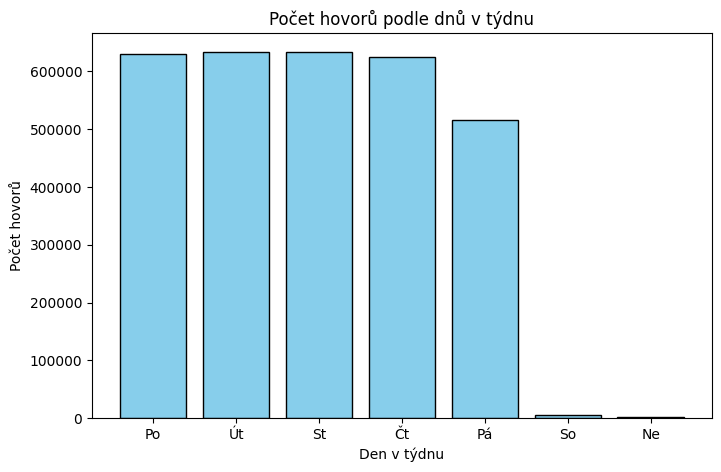

In [61]:
# Průměrný počet hovorů rozdělených na dny (Po - Ne) za poslední čtvrtletí
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])
dni = {'Po':0, 'Út':0, 'St':0, 'Čt':0, 'Pá':0, 'So':0, 'Ne':0}

for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):
        den = date.weekday()  # pondělí=0, neděle=6
        if den == 0:
            dni['Po'] += 1
        elif den == 1:
            dni['Út'] += 1
        elif den == 2:
            dni['St'] += 1
        elif den == 3:
            dni['Čt'] += 1
        elif den == 4:
            dni['Pá'] += 1
        elif den == 5:
            dni['So'] += 1
        elif den == 6:
            dni['Ne'] += 1

print("Počet hovorů podle dnů v týdnu:")
for den, pocet in dni.items():
    print(f"{den}: {pocet}")

nazvy_dnu = list(dni.keys())
pocet_hovoru = list(dni.values())

plt.figure(figsize=(8,5))
plt.bar(nazvy_dnu, pocet_hovoru, color='skyblue', edgecolor='black')
plt.title('Počet hovorů podle dnů v týdnu')
plt.xlabel('Den v týdnu')
plt.ylabel('Počet hovorů')
plt.show()

Počet hovorů podle časových bloků:
6-12: 2013006
12-18: 1023266
18-24: 7310
0-6: 4099


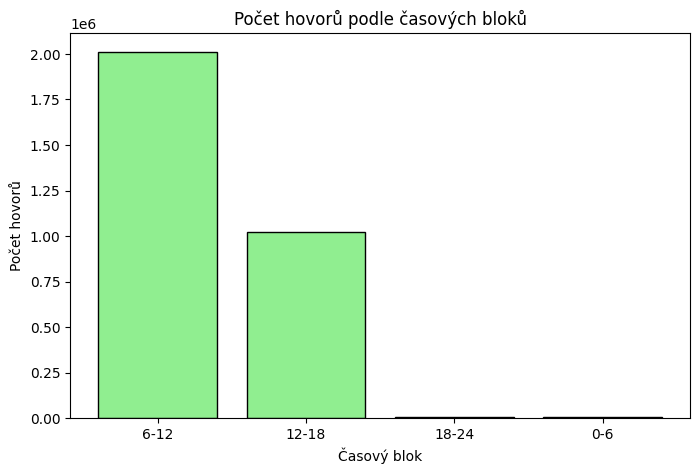

In [64]:
# Kdy se nejčastěji volá dle jednotlivých dnů 6-12, 12-18, 18-24 a 24-6
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])
casove_bloky = {'6-12':0, '12-18':0, '18-24':0, '0-6':0}

for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):
        hodina = date.hour
        if 6 <= hodina < 12:
            casove_bloky['6-12'] += 1
        elif 12 <= hodina < 18:
            casove_bloky['12-18'] += 1
        elif 18 <= hodina < 24:
            casove_bloky['18-24'] += 1
        else:  # 0-6
            casove_bloky['0-6'] += 1

print("Počet hovorů podle časových bloků:")
for blok, pocet in casove_bloky.items():
    print(f"{blok}: {pocet}")

nazvy_bloku = list(casove_bloky.keys())
pocet_hovoru = list(casove_bloky.values())

plt.figure(figsize=(8,5))
plt.bar(nazvy_bloku, pocet_hovoru, color='lightgreen', edgecolor='black')
plt.title('Počet hovorů podle časových bloků')
plt.xlabel('Časový blok')
plt.ylabel('Počet hovorů')
plt.show()

Distribuce hovorů v bloku 6-12 po hodinách:
6:00 - 42049 hovorů
7:00 - 351761 hovorů
8:00 - 471434 hovorů
9:00 - 470897 hovorů
10:00 - 449046 hovorů
11:00 - 227819 hovorů


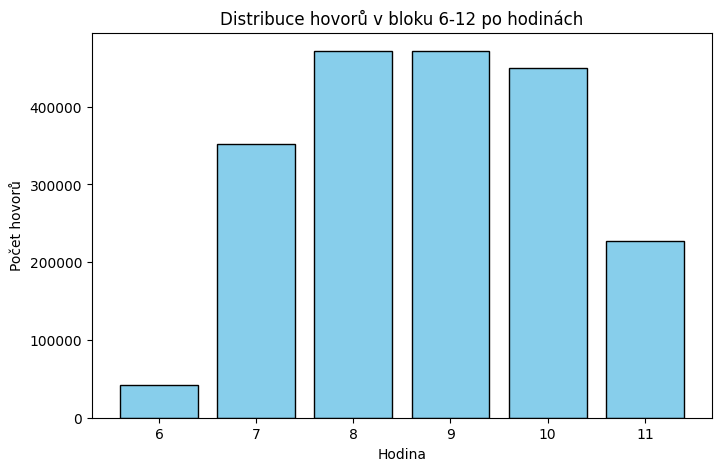

In [ ]:
unique_calls_df = df.drop_duplicates(subset=["globalCallID_callId", "origLegCallIdentifier"])
blok_6_12 = {6:0, 7:0, 8:0, 9:0, 10:0, 11:0}

for date in unique_calls_df['dateTimeOrigination']:
    if pd.notna(date):
        hodina = date.hour
        if 6 <= hodina < 12:
            blok_6_12[hodina] += 1


print("Distribuce hovorů v bloku 6-12 po hodinách:")
for hod, pocet in blok_6_12.items():
    print(f"{hod}:00 - {pocet} hovorů")


hodiny = list(blok_6_12.keys())
pocet_hovoru = list(blok_6_12.values())

plt.figure(figsize=(8,5))
plt.bar(hodiny, pocet_hovoru, color='skyblue', edgecolor='black')
plt.title('Distribuce hovorů v bloku 6-12 po hodinách')
plt.xlabel('Hodina')
plt.ylabel('Počet hovorů')
plt.xticks(hodiny) 
plt.show()